In [62]:
# ================================================
# HEART DISEASE PREDICTION — FULL CLEAN NOTEBOOK
# Stacked Generalization + SHAP on UCI Cleveland
# ================================================

# 1.) SETUP --- #Importing libraries

import os
os.makedirs('figures', exist_ok=True)

!pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import shap

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" Setup complete | Figures will be saved in ./figures/")

 Setup complete | Figures will be saved in ./figures/


In [63]:
# 2. LOAD DATA & BASIC EDA
heart_prediction = pd.read_csv("Heart_disease_cleveland_new.csv")

print("Dataset shape:", heart_prediction.shape)
print("\nInfo about Data", heart_prediction.info() )
print("\nDescriptive Statistics about The Data")
print(heart_prediction.describe())
print("\nTarget distribution:\n", heart_prediction['target'].value_counts())
print("\nMissing values:\n", heart_prediction.isnull().sum())

# Feature types
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Dataset shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Info about Data None

Descriptive Statistics about The Data
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.00000

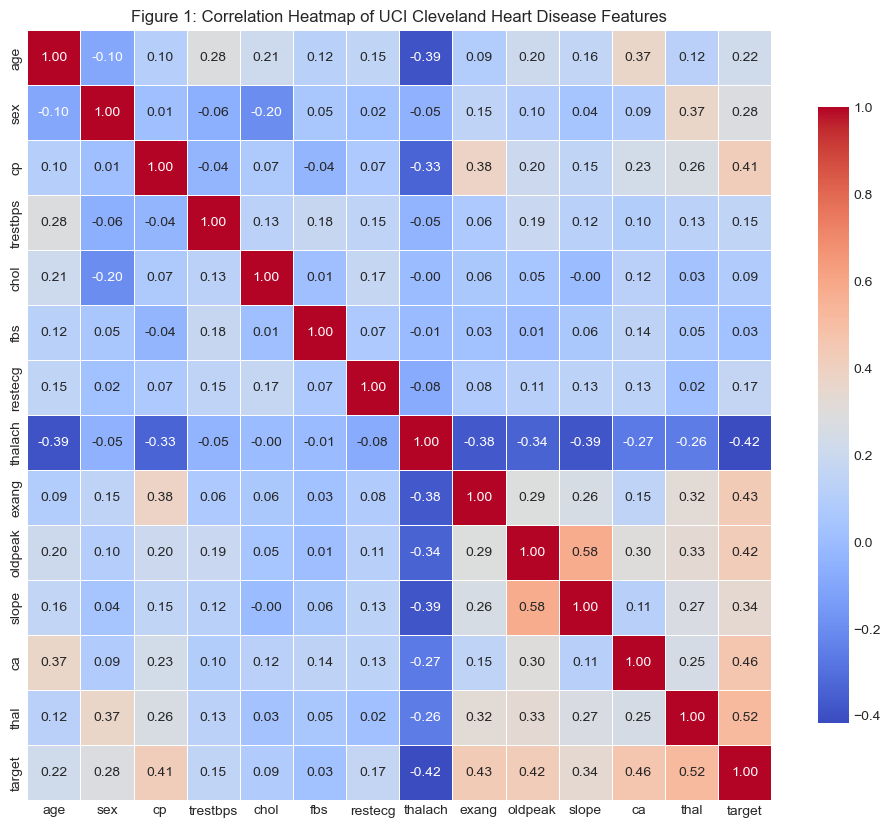

In [64]:
# 3. EDA VISUALIZATIONS 

# Correlation Heatmap 
plt.figure(figsize=(12, 10))
corr = heart_prediction.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Figure 1: Correlation Heatmap of UCI Cleveland Heart Disease Features')
plt.savefig('figures/fig1_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig1_correlation_heatmap.pdf', bbox_inches='tight')
plt.show()

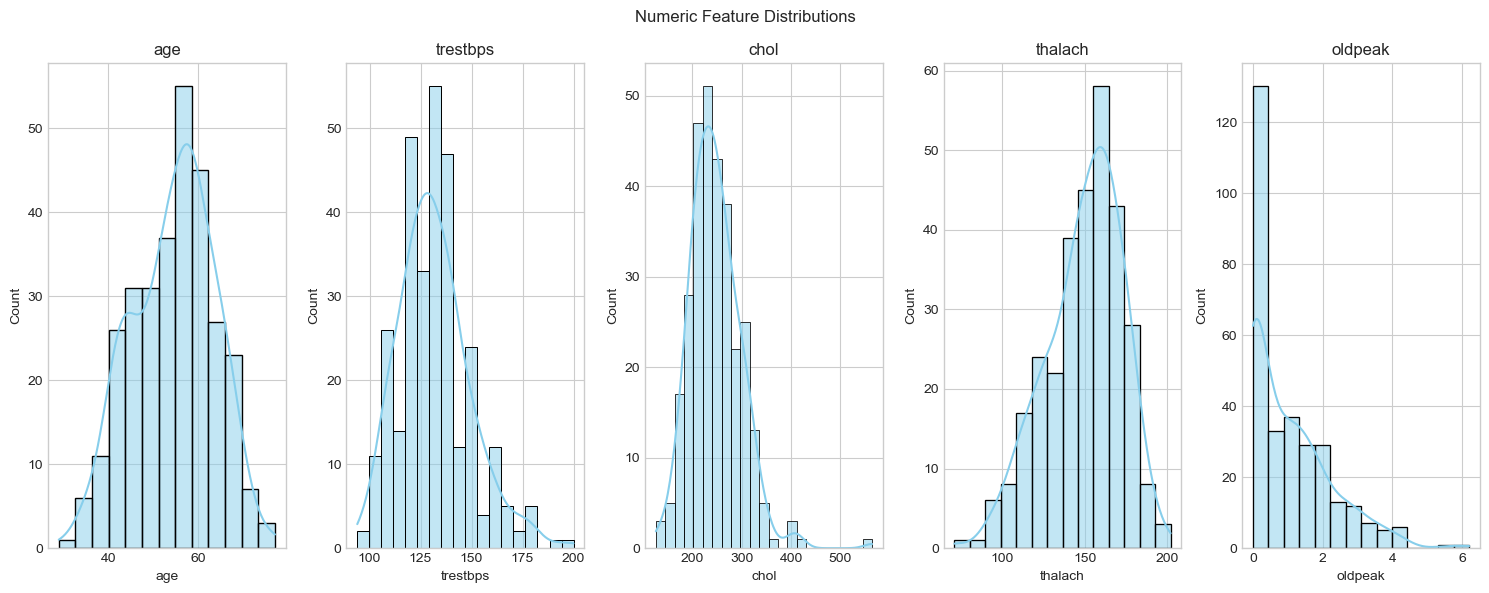

In [65]:
# 3b. EDA VISUALIZATIONS 
# Numeric Feature Distributions
plt.figure(figsize=(15, 6))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, 5, i)
    sns.histplot(heart_prediction[col], kde=True, color='skyblue')
    plt.title(col)
plt.suptitle('Numeric Feature Distributions')
plt.tight_layout()
plt.savefig('figures/fig_2_eda_numeric_distributions.png', dpi=300)
plt.savefig('figures/fig_2_eda_numeric_distributions.pdf', bbox_inches='tight')
plt.show()

In [66]:
# 4. PREPROCESSING 
X = heart_prediction.drop('target', axis=1)
y = heart_prediction['target']

#SPLIT DATA INTO TEST-TRAIN SET
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# Scale numeric + One-hot categorical
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_features])
X_test_num  = scaler.transform(X_test[numeric_features])

# Encode categorical columns
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat  = encoder.transform(X_test[categorical_features])

# Combine back together
X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final  = np.hstack([X_test_num, X_test_cat])

print(f"Final shapes -> Train: {X_train_final.shape} | Test: {X_test_final.shape}")

Final shapes -> Train: (212, 20) | Test: (91, 20)


In [67]:
# 5. HYPERPARAMETER TUNING
def tune_and_save(model, param_grid, name):
    grid = GridSearchCV(
        model, param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc', n_jobs=-1, verbose=0
    )
    grid.fit(X_train_final, y_train)
    print(f"{name} Best CV AUC: {grid.best_score_:.4f} | Params: {grid.best_params_}")
    return grid.best_estimator_, grid.best_score_

# 1. Logistic Regression
lr = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
lr_grid = {'C': [0.01, 0.1, 1.0, 10.0, 50.0], 'penalty': ['l2']}
best_lr, lr_cv = tune_and_save(lr, lr_grid, "Logistic Regression")

# 2. Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf_grid = {'n_estimators': [300], 'max_depth': [8], 'min_samples_split': [2], 'min_samples_leaf': [1]}
best_rf, rf_cv = tune_and_save(rf, rf_grid, "Random Forest")

# 3. XGBoost
xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
xgb_grid = {'n_estimators': [300], 'max_depth': [3], 'learning_rate': [0.01], 'subsample': [0.8]}
best_xgb, xgb_cv = tune_and_save(xgb, xgb_grid, "XGBoost")

# 4. SVM
svm = SVC(probability=True, random_state=RANDOM_STATE)
svm_grid = {'C': [50.0], 'gamma': [0.001], 'kernel': ['rbf']}
best_svm, svm_cv = tune_and_save(svm, svm_grid, "SVM")

Logistic Regression Best CV AUC: 0.8959 | Params: {'C': 1.0, 'penalty': 'l2'}
Random Forest Best CV AUC: 0.9004 | Params: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
XGBoost Best CV AUC: 0.8905 | Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
SVM Best CV AUC: 0.8951 | Params: {'C': 50.0, 'gamma': 0.001, 'kernel': 'rbf'}


In [68]:
# 6. STACKING ENSEMBLE
estimators = [('lr', best_lr), ('rf', best_rf), ('xgb', best_xgb), ('svm', best_svm)]

stacker = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)
stacker.fit(X_train_final, y_train)

y_pred_stack = stacker.predict(X_test_final)
y_prob_stack = stacker.predict_proba(X_test_final)[:, 1]

stack_metrics = {
    'Model':     'Stacking Ensemble',
    'Accuracy':  accuracy_score(y_test, y_pred_stack),
    'Precision': precision_score(y_test, y_pred_stack),
    'Recall':    recall_score(y_test, y_pred_stack),
    'F1':        f1_score(y_test, y_pred_stack),
    'AUC-ROC':   roc_auc_score(y_test, y_prob_stack)
}

print("\n" + "="*50)
print("STACKING ENSEMBLE — TEST SET PERFORMANCE")
print("="*50)
for metric, value in stack_metrics.items():
    if metric != 'Model':
        print(f"{metric:12}: {value:.4f}")
print("="*50)



STACKING ENSEMBLE — TEST SET PERFORMANCE
Accuracy    : 0.8571
Precision   : 0.8537
Recall      : 0.8333
F1          : 0.8434
AUC-ROC     : 0.9320



FINAL TEST SET PERFORMANCE (all models)
              Model  Accuracy  Precision  Recall     F1  AUC-ROC
Logistic Regression    0.8681     0.8750  0.8333 0.8537   0.9378
      Random Forest    0.7912     0.7674  0.7857 0.7765   0.9077
            XGBoost    0.7692     0.7838  0.6905 0.7342   0.8975
                SVM    0.8462     0.8684  0.7857 0.8250   0.9325
  Stacking Ensemble    0.8571     0.8537  0.8333 0.8434   0.9320

----------------------------------------------------------------------
Stacking AUC-ROC             : 0.9320
Best single model (Logistic Regression) : 0.9378
Difference (Stacking - Best) : -0.0058
----------------------------------------------------------------------
→ HYPOTHESIS H1 NOT SUPPORTED in this run
  Stacking did not improve over best single model (-0.0058)


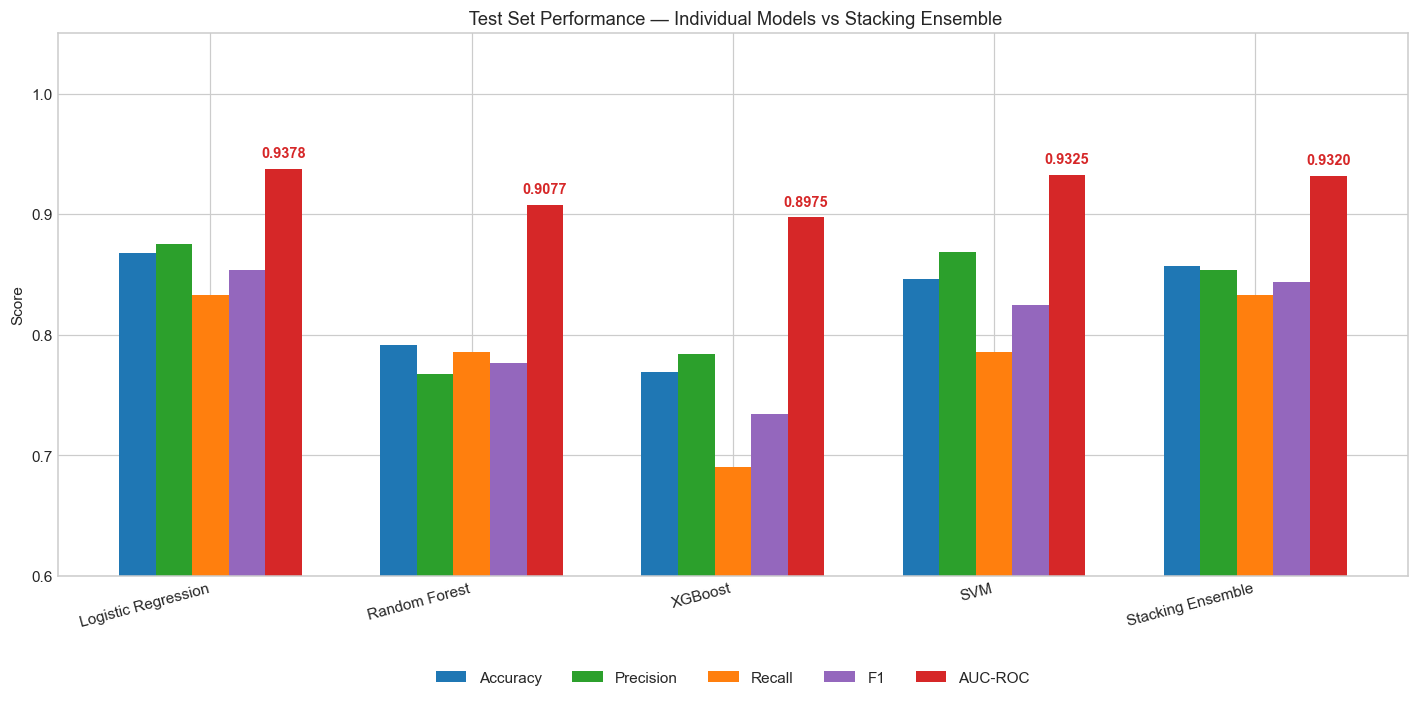

In [74]:
# 7. TEST SET EVALUATION + FIGURE (Performance Bar Chart) 
test_results = []
for name, model in [('Logistic Regression', best_lr), ('Random Forest', best_rf),
                    ('XGBoost', best_xgb), ('SVM', best_svm)]:
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1]
    test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    })

# Append stacking row so the Figure shows all 5 models together
test_results.append(stack_metrics)

test_df = pd.DataFrame(test_results).round(4)
print("\nFINAL TEST SET PERFORMANCE (all models)")
print(test_df.to_string(index=False))

# Compare stacking vs best single model
single_df  = test_df[test_df['Model'] != 'Stacking Ensemble']
best_single = single_df.loc[single_df['AUC-ROC'].idxmax()]
diff        = stack_metrics['AUC-ROC'] - best_single['AUC-ROC']

print("\n" + "-"*70)
print(f"Stacking AUC-ROC             : {stack_metrics['AUC-ROC']:.4f}")
print(f"Best single model ({best_single['Model']}) : {best_single['AUC-ROC']:.4f}")
print(f"Difference (Stacking - Best) : {diff:+.4f}")
print("-"*70)

if diff >= 0.04:
    print("→ HYPOTHESIS H1 SUPPORTED")
    print("  Stacking outperforms best single model by >= 4 percentage points")
elif diff > 0:
    print("→ Partial support / small improvement")
    print(f"  Stacking improves performance (+{diff:.4f}), but gain < 4 pp")
else:
    print("→ HYPOTHESIS H1 NOT SUPPORTED in this run")
    print(f"  Stacking did not improve over best single model ({diff:+.4f})")
print("="*70)

# Bar chart — all 5 models including stacking
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
colors  = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#d62728']

fig, ax = plt.subplots(figsize=(13, 6.5), dpi=110)
x     = np.arange(len(test_df))
width = 0.14

for i, metric in enumerate(metrics):
    ax.bar(x + width * (i - 2), test_df[metric], width=width, label=metric, color=colors[i])

# Annotate AUC-ROC values on top of each group
for i, auc in enumerate(test_df['AUC-ROC']):
    ax.text(x[i] + width * 2, auc + 0.007, f'{auc:.4f}',
            ha='center', va='bottom', fontweight='bold', color='#d62728', fontsize=9.5)

ax.set_ylim(0.60, 1.05)
ax.set_ylabel('Score')
ax.set_title(' Test Set Performance — Individual Models vs Stacking Ensemble')
ax.set_xticks(x)
ax.set_xticklabels(test_df['Model'], rotation=15, ha='right')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
plt.tight_layout()
plt.savefig('figures/fig3_test_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig3_test_performance_comparison.pdf', bbox_inches='tight')
plt.show()


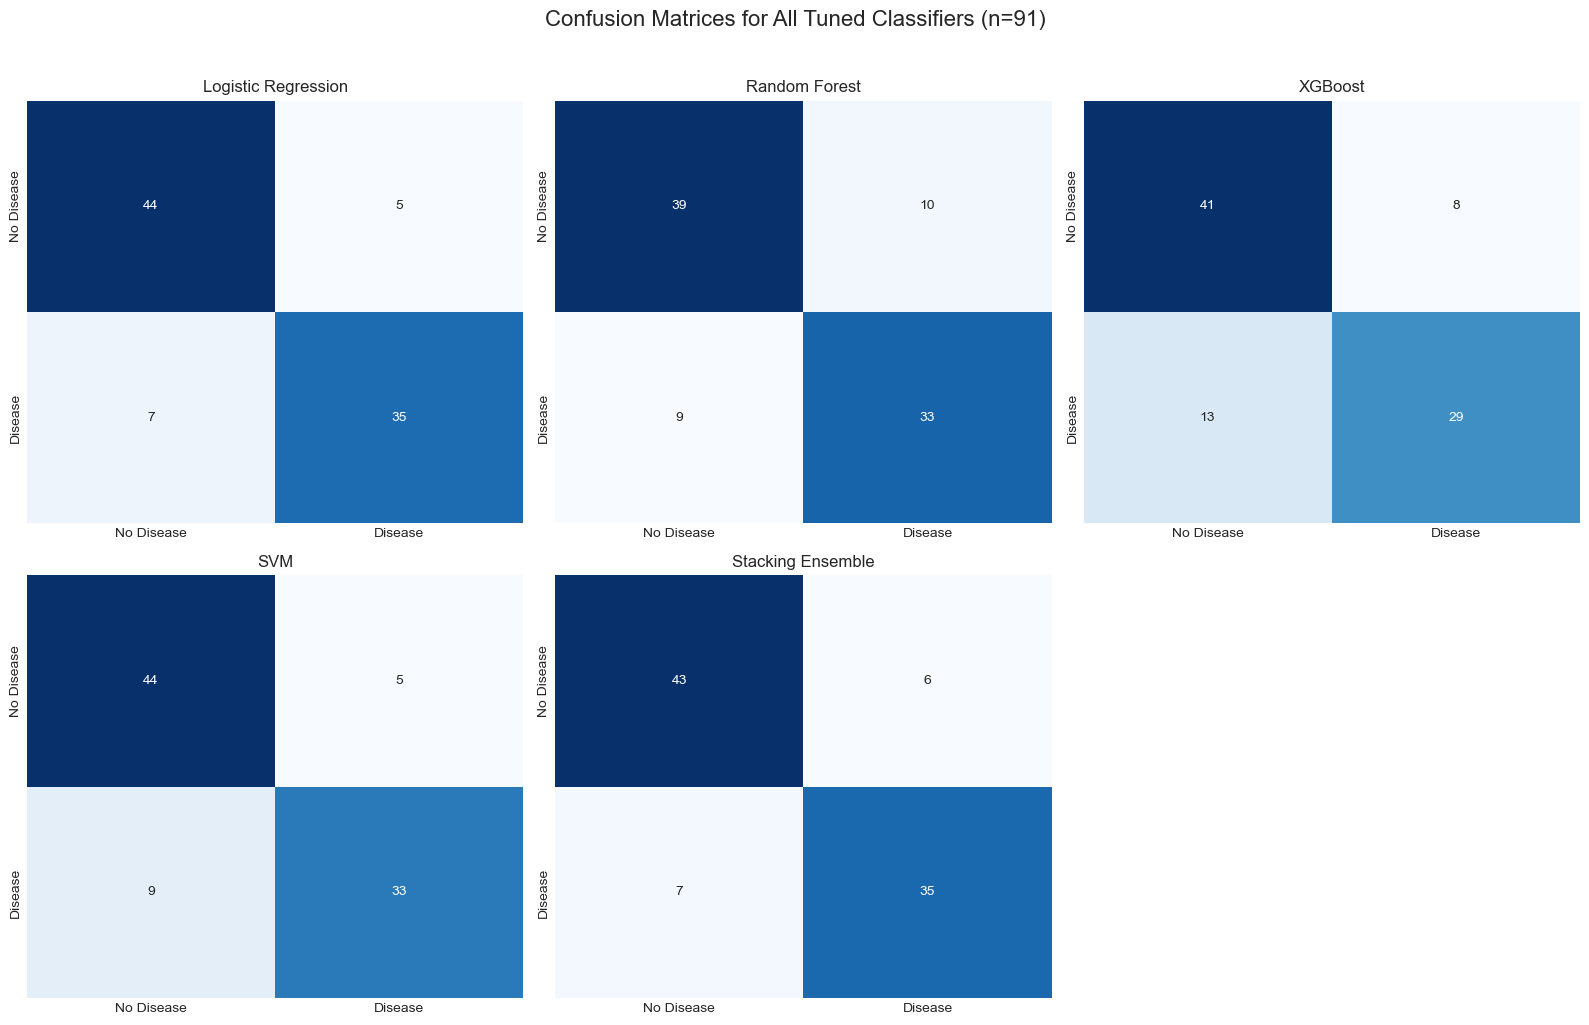

In [70]:
# 8. CONFUSION MATRICES
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'], ax=ax)
    ax.set_title(title)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

models_list = [
    ("Logistic Regression", best_lr.predict(X_test_final)),
    ("Random Forest", best_rf.predict(X_test_final)),
    ("XGBoost", best_xgb.predict(X_test_final)),
    ("SVM", best_svm.predict(X_test_final)),
    ("Stacking Ensemble", y_pred_stack)
]

for i, (name, pred) in enumerate(models_list):
    plot_cm(y_test, pred, name, axes[i])

for j in range(len(models_list), len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices for All Tuned Classifiers (n=91)', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('figures/fig4_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig4_confusion_matrices.pdf', bbox_inches='tight')
plt.show()

Logistic Regression  → mean CV AUC = 0.8959  (std = 0.0382)
Random Forest        → mean CV AUC = 0.9004  (std = 0.0290)
XGBoost              → mean CV AUC = 0.8905  (std = 0.0353)
SVM                  → mean CV AUC = 0.8951  (std = 0.0386)


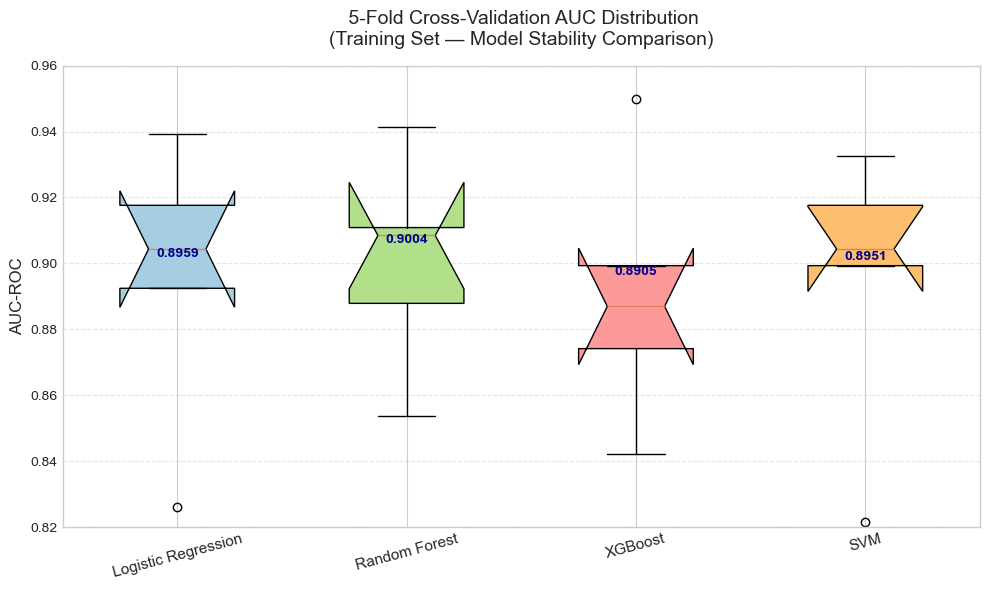

In [73]:
# 9. CROSS-VALIDATION STABILITY 

print("Collecting 5-fold CV scores...")

models_cv = {
    'Logistic Regression': best_lr,
    'Random Forest':       best_rf,
    'XGBoost':             best_xgb,
    'SVM':                 best_svm
}

cv_scores_dict = {}
cv_means       = []

for name, model in models_cv.items():
    scores = cross_val_score(
        model, X_train_final, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc', n_jobs=-1
    )
    cv_scores_dict[name] = scores
    cv_means.append(scores.mean())
    print(f"{name:20} → mean CV AUC = {scores.mean():.4f}  (std = {scores.std():.4f})")

# Boxplot
plt.figure(figsize=(10, 6))
bp = plt.boxplot(
    cv_scores_dict.values(),
    tick_labels=cv_scores_dict.keys(),
    patch_artist=True,
    notch=True,
    widths=0.5
)

box_colors = ['#a6cee3', '#b2df8a', '#fb9a99', '#fdbf6f']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

plt.title(' 5-Fold Cross-Validation AUC Distribution\n(Training Set — Model Stability Comparison)',
          fontsize=14, pad=15)
plt.ylabel('AUC-ROC', fontsize=12)
plt.ylim(0.82, 0.96)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=15, fontsize=11)

for i, mean in enumerate(cv_means):
    plt.text(i + 1, mean + 0.005, f'{mean:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.savefig('figures/fig5_cv_auc_boxplot.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig5_cv_auc_boxplot.pdf', bbox_inches='tight')
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_15280\474245203.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_final, plot_type="bar",


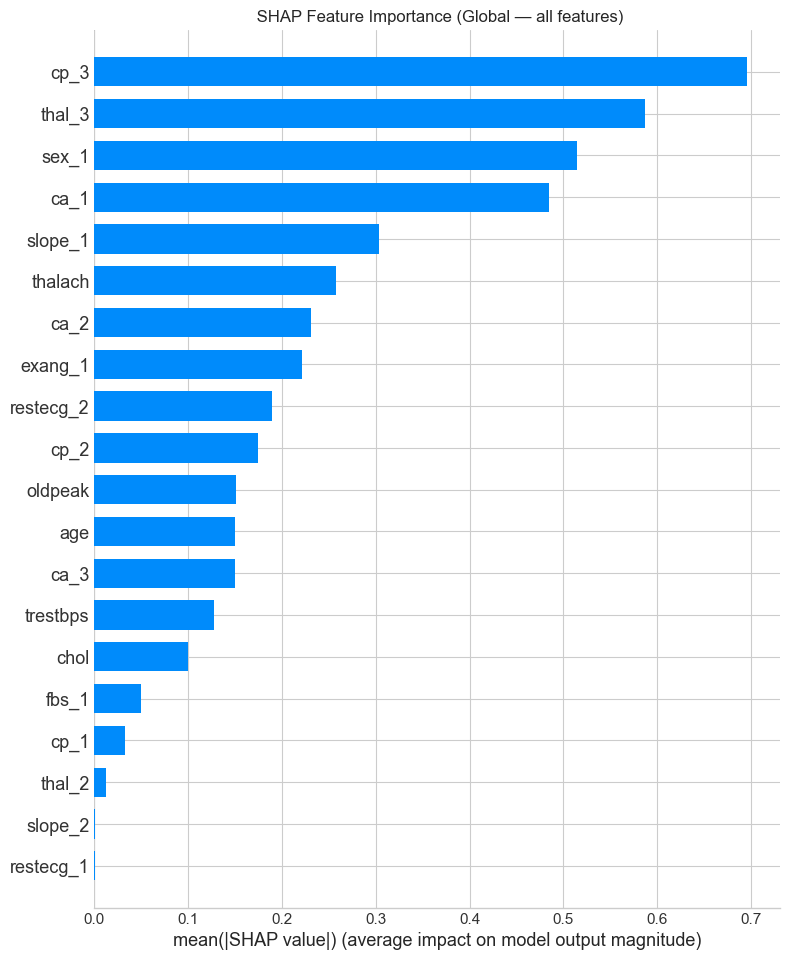

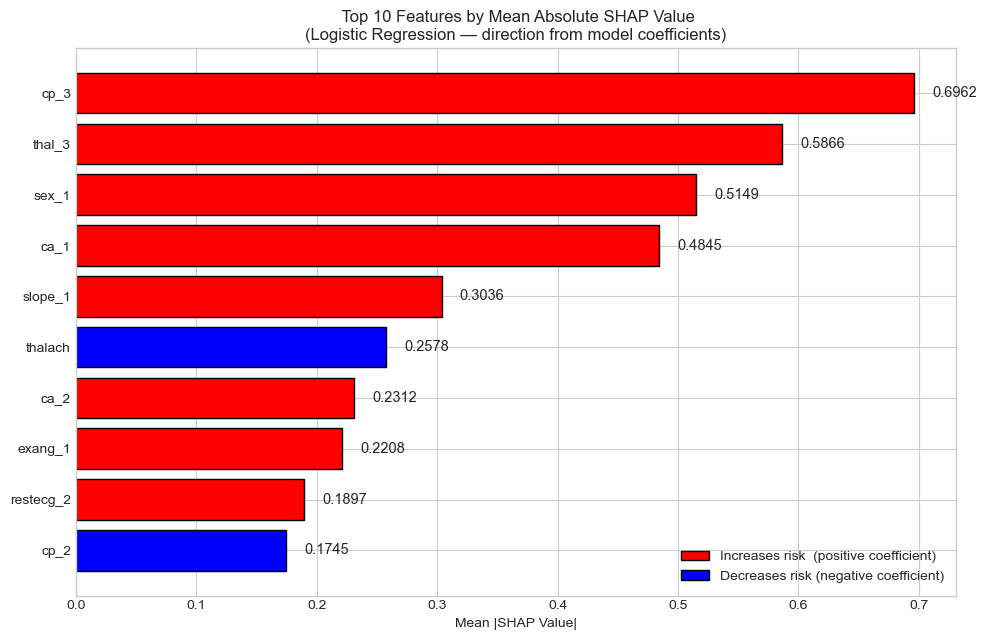


All figures saved:
  fig1_correlation_heatmap          → EDA
  fig2_test_performance_comparison  → Numericfeature Distribution
  fig3_test_performance_comparison  → All models test results (incl. stacking)
  fig4_confusion_matrices           → Confusion matrices
  fig5_cv_auc_boxplot               → Cross-validation stability
  fig6a_shap_summary_bar            → SHAP global importance
  fig6b_shap_top10_bar              → SHAP top 10 with correct direction colours


In [72]:
# 10. SHAP ANALYSIS 

# Build feature name array matching the encoded columns
cat_names    = encoder.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_names])

# Compute SHAP values using LinearExplainer (correct for Logistic Regression)
explainer   = shap.LinearExplainer(best_lr, X_train_final)
shap_values = explainer(X_train_final)

# SHAP global summary bar (all features)
shap.summary_plot(shap_values, X_train_final, plot_type="bar",
                  feature_names=feature_names, show=False)
plt.title(' SHAP Feature Importance (Global — all features)')
plt.savefig('figures/fig6a_shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig6a_shap_summary_bar.pdf', bbox_inches='tight')
plt.show()

# Top-10 coloured bar — direction from model coefficients (not mean SHAP)
coef_direction = np.sign(best_lr.coef_[0])   # +1 or -1 per feature

shap_importance = pd.DataFrame({
    'Feature':    feature_names,
    'Mean |SHAP|': np.abs(shap_values.values).mean(axis=0),
    'Direction':   coef_direction
}).sort_values('Mean |SHAP|', ascending=False)

top10 = shap_importance.head(10).copy().sort_values('Mean |SHAP|', ascending=True)
top10['color'] = np.where(top10['Direction'] > 0, 'red', 'blue')

fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(top10['Feature'], top10['Mean |SHAP|'],
               color=top10['color'], edgecolor='black')

for bar, val in zip(bars, top10['Mean |SHAP|']):
    ax.text(val + 0.015, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10.5)

legend_elements = [
    Patch(facecolor='red',  edgecolor='black', label='Increases risk  (positive coefficient)'),
    Patch(facecolor='blue', edgecolor='black', label='Decreases risk (negative coefficient)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title(' Top 10 Features by Mean Absolute SHAP Value\n'
             '(Logistic Regression — direction from model coefficients)')
plt.tight_layout()
plt.savefig('figures/fig6b_shap_top10_bar.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig6b_shap_top10_bar.pdf', bbox_inches='tight')
plt.show()

print("\nAll figures saved:")
print("  fig1_correlation_heatmap          → EDA")
print("  fig2_test_performance_comparison  → Numericfeature Distribution")
print("  fig3_test_performance_comparison  → All models test results (incl. stacking)")
print("  fig4_confusion_matrices           → Confusion matrices")
print("  fig5_cv_auc_boxplot               → Cross-validation stability")
print("  fig6a_shap_summary_bar            → SHAP global importance")
print("  fig6b_shap_top10_bar              → SHAP top 10 with correct direction colours")
